# EfficientNet-B0 - Image-Only Fraud Detection

EfficientNet-B0 baseline for binary fraud classification on the multimodal image dataset.

**Experiment 1**: Unweighted loss (baseline - no imbalance correction)

**Experiment 2**: Weighted loss (pos_weight correction)

Threshold selection: **minimum expected cost** on the validation set
(FN × $50,000 + FP × $500) - identical to tabular notebooks 11 and 12.


In [1]:
import sys, random, torch
from pathlib import Path
import pandas as pd

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

from efficientnet_utils import (
    build_model, unfreeze_backbone, fit_model,
    predict_probs, build_train_transform, build_val_transform,
)
from mm_image_utils import load_mm_splits, build_mm_dataloaders, make_loss_fn
from torch import nn

def set_seed(seed: int) -> None:
    random.seed(seed); __import__("numpy").random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Random seed: {SEED}")
print(f"Device     : {device}")


Random seed: 42
Device     : cpu


In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_BASE = PROJECT_ROOT / "notebook" / "results" / "mm_image_efficientnet_b0"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE      = 32
NUM_WORKERS     = 0
STAGE1_EPOCHS   = 5;   STAGE1_LR   = 1e-3;  STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20;  BACKBONE_LR = 1e-5;  HEAD_LR         = 1e-4
STAGE2_PATIENCE = 6
DROPOUT         = 0.4

EXP_DIRS = {
    "A_unweighted": RESULTS_BASE / "B_unweighted",
    "B_weighted":   RESULTS_BASE / "A_weighted",
}
for d in EXP_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results base:", RESULTS_BASE)


Project root: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Results base: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_b0


# Image-only baseline


In [3]:
train_df, val_df, test_df = load_mm_splits(TRAIN_CSV, VAL_CSV, TEST_CSV)

train_loader, val_loader, test_loader = build_mm_dataloaders(
    train_df, val_df, test_df,
    train_transform=build_train_transform(),
    val_transform=build_val_transform(),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, use_sampler=False,
)
print(f"Batches — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")
print("\nTrain class counts:")
print(train_df["final_label"].value_counts())

LOSS_FNS = {
    "A_unweighted": nn.BCEWithLogitsLoss().to(device),
    "B_weighted":   make_loss_fn(train_df, device),
}


train: 7,182 rows | label 0:2,588 label 1:4,594 ratio 1:1.78
  combos: {'tab0_img0': 2588, 'tab0_img1': 1866, 'tab1_img0': 863, 'tab1_img1': 1865}
val: 1,508 rows | label 0:557 label 1:951 ratio 1:1.71
  combos: {'tab0_img0': 557, 'tab0_img1': 382, 'tab1_img0': 186, 'tab1_img1': 383}
test: 1,474 rows | label 0:554 label 1:920 ratio 1:1.66
  combos: {'tab0_img0': 554, 'tab0_img1': 368, 'tab1_img0': 185, 'tab1_img1': 367}
Batches — train:225 val:48 test:47

Train class counts:
final_label
1    4594
0    2588
Name: count, dtype: int64
  pos_weight = 0.563  (n_neg=2588, n_pos=4594)  [DOWN-weighting fraud (majority)]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
)

FN_COST = 50_000
FP_COST = 500

def evaluate_image_model(y_true, y_prob, split_name="split", threshold=0.5):
    """Mirrors evaluate_model() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "split": split_name,
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_true, y_prob)),
        "pr_auc":    float(average_precision_score(y_true, y_prob)),
    }
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n=== {split_name.upper()} ===")
    for k, v in metrics.items():
        if k != "split": print(f"{k}: {v:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def search_thresholds_image(y_true, y_prob,
                             thresholds=np.arange(0.10, 1.00, 0.05)):
    """Mirrors search_thresholds() from tabular utils."""
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold":       round(float(t), 4),
            "precision":       float(precision_score(y_true, y_pred, zero_division=0)),
            "recall":          float(recall_score(y_true,    y_pred, zero_division=0)),
            "f1":              float(f1_score(y_true,        y_pred, zero_division=0)),
            "predicted_fraud": int(y_pred.sum()),
        })
    return pd.DataFrame(rows)

def compute_cost_table_image(threshold_results, y_val_true,
                              fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_cost_table() from tabular utils."""
    n_pos = int((y_val_true == 1).sum())
    n_neg = int((y_val_true == 0).sum())
    rows = []
    for _, row in threshold_results.iterrows():
        tp = round(row["recall"] * n_pos)
        fn = n_pos - tp
        fp = row["predicted_fraud"] - tp
        tn = n_neg - fp
        rows.append({
            "threshold": row["threshold"],
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": row["precision"],
            "recall":    row["recall"],
            "f1":        row["f1"],
            "predicted_fraud": row["predicted_fraud"],
            "expected_cost":   int(fn * fn_cost + fp * fp_cost),
        })
    return pd.DataFrame(rows).sort_values("expected_cost").reset_index(drop=True)

def evaluate_image_with_threshold(y_true, y_prob, threshold):
    """Mirrors evaluate_with_threshold() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
    }
    print(f"\nTuned threshold: {threshold}")
    print(f"Precision: {metrics['precision']:.6f}")
    print(f"Recall:    {metrics['recall']:.6f}")
    print(f"F1:        {metrics['f1']:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def compute_expected_cost_from_cm(cm, fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_expected_cost_from_cm() from tabular utils."""
    tn, fp, fn, tp = cm.ravel()
    return {"tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "expected_cost": int(fn * fn_cost + fp * fp_cost)}

def save_image_experiment_outputs(results_dir, test_y_true, test_y_prob,
                                   threshold_results, cost_df,
                                   tuned_metrics, tuned_cm,
                                   val_metrics, test_metrics, prefix):
    """Mirrors save_experiment_outputs() from tabular utils."""
    from pathlib import Path
    results_dir = Path(results_dir)
    pred_df = pd.DataFrame({"y_true": test_y_true, "y_prob": test_y_prob})
    pred_df["y_pred"] = (pred_df["y_prob"] >= tuned_metrics["threshold"]).astype(int)
    pred_df.to_csv(results_dir / "test_predictions.csv", index=False)
    threshold_results.to_csv(results_dir / f"{prefix}_threshold_results.csv", index=False)
    cost_df.to_csv(results_dir / f"{prefix}_cost_results.csv", index=False)
    pd.DataFrame([tuned_metrics]).to_csv(results_dir / f"{prefix}_tuned_metrics.csv", index=False)
    pd.DataFrame(tuned_cm, index=["true_0","true_1"],
                 columns=["pred_0","pred_1"]).to_csv(
        results_dir / f"{prefix}_tuned_cm.csv")
    pd.DataFrame([val_metrics, test_metrics]).to_csv(
        results_dir / f"{prefix}_metrics_summary.csv", index=False)

def plot_model_diagnostics_pretty(cm, threshold_results, cost_df, model_name,
                                   fn_cost=FN_COST, fp_cost=FP_COST, save_path=None):
    """Copied from notebooks 11 and 12 — identical function."""
    cm = np.asarray(cm).astype(int)
    threshold_df   = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")
    best_row            = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold      = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])
    tn, fp, fn, tp = cm.ravel()
    test_expected_cost  = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    fig.patch.set_facecolor("white")

    ax = axes[0]
    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())
    im = ax.imshow(cm_for_color, cmap="Blues", norm=norm)
    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            value = cm[i,j]
            rgba  = im.cmap(norm(cm_for_color[i,j]))
            lum   = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            ax.text(j, i, f"{value:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if lum < 0.45 else "#08306b")
    for sp in ax.spines.values(): sp.set_visible(False)

    ax = axes[1]
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2.2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"],    linewidth=2.2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"],        linewidth=2.2, label="F1")
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.text(0.98, 0.95, f"Best threshold = {best_threshold:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(frameon=False, loc="lower left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[2]
    ax.plot(cost_df_sorted["threshold"], cost_df_sorted["expected_cost"],
            linewidth=2.2, marker="o", markersize=4)
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.scatter(best_threshold, best_validation_cost, s=80, color="black", zorder=5)
    ax.annotate(f"Min cost: ${best_validation_cost/1_000_000:.2f}M",
                xy=(best_threshold, best_validation_cost), xytext=(18,18),
                textcoords="offset points", fontsize=10,
                arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{model_name} diagnostics | Tuned test cost: ${test_expected_cost/1_000_000:.2f}M",
        fontsize=15, fontweight="bold")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print("All helper functions defined.")


All helper functions defined.


## 1. EfficientNet-B0 - without loss weighting

Standard BCEWithLogitsLoss with no class weight correction.


In [5]:
results_dir = EXP_DIRS["A_unweighted"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved 1. EfficientNet-B0 — without loss weighting model...")
    model_unweighted = build_model(pretrained=False, freeze_backbone=False,
                               dropout=DROPOUT).to(device)
    model_unweighted.load_state_dict(torch.load(model_path, map_location=device))
    model_unweighted.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training 1. EfficientNet-B0 — without loss weighting model...")
    model_unweighted = build_model(pretrained=True, freeze_backbone=True,
                               dropout=DROPOUT).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_unweighted.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_unweighted, h_s1 = fit_model(
        model=model_unweighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["A_unweighted"], optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=results_dir / "stage1_best.pt",
    )
    unfreeze_backbone(model_unweighted)
    bp = [p for n, p in model_unweighted.named_parameters() if "classifier" not in n]
    hp = list(model_unweighted.classifier.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": BACKBONE_LR},
         {"params": hp, "lr": HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_unweighted, h_s2 = fit_model(
        model=model_unweighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["A_unweighted"], optimizer=opt2, scheduler=sched,
        device=device, epochs=STAGE2_EPOCHS,
        early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc", freeze_bn=True,
        model_save_path=model_path,
    )
    hist = pd.concat([h_s1.assign(stage=1), h_s2.assign(stage=2)], ignore_index=True)
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_b0\B_unweighted\stage2_best.pt
Model exists: True
Already trained. Loading saved 1. EfficientNet-B0 — without loss weighting model...
EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
Model loaded successfully.


In [6]:
val_y_unweighted, val_p_unweighted = predict_probs(model_unweighted, val_loader,  device)
test_y_unweighted,    test_p_unweighted  = predict_probs(model_unweighted, test_loader, device)

val_metrics_unweighted,  val_cm_unweighted  = evaluate_image_model(
    val_y_unweighted, val_p_unweighted, split_name="validation_unweighted")
test_metrics_unweighted, test_cm_unweighted = evaluate_image_model(
    test_y_unweighted,    test_p_unweighted,  split_name="test_unweighted")



=== VALIDATION_UNWEIGHTED ===
accuracy: 0.828249
precision: 0.884444
recall: 0.837014
f1: 0.860076
roc_auc: 0.876069
pr_auc: 0.936963

Confusion matrix:
[[453 104]
 [155 796]]

=== TEST_UNWEIGHTED ===
accuracy: 0.831750
precision: 0.891608
recall: 0.831522
f1: 0.860517
roc_auc: 0.883360
pr_auc: 0.938623

Confusion matrix:
[[461  93]
 [155 765]]


### EfficientNet-B0 unweighted baseline results

The unweighted EfficientNet-B0 image-only model shows stable performance on validation and test data. On the validation set, it achieves an F1-score of 0.8601, and on the test set the F1-score is very similar at 0.8605. This suggests that the model generalizes consistently.

On the test set, precision is 0.8916 and recall is 0.8315. This means that most predicted fraud cases are correct, but the model still misses some fraud cases. The confusion matrix shows that the model correctly detects 765 fraud cases and misses 155. It also incorrectly flags 93 legitimate cases as fraud.

The ROC-AUC is 0.8834 and PR-AUC is 0.9386, which indicates that the model learns useful image-based fraud signals. The results are very close to the ResNet18 image-only baseline, so EfficientNet-B0 does not clearly outperform ResNet18 in this setting.

Overall, the unweighted EfficientNet-B0 model provides a solid image-only baseline. It can detect many fraud cases from image information, but it still misses a noticeable number of fraud cases, so image-only learning remains limited.

In [7]:
threshold_results_unweighted = search_thresholds_image(val_y_unweighted, val_p_unweighted)
print(threshold_results_unweighted)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.631474  1.000000  0.774115             1506
1        0.15   0.633869  0.995794  0.774642             1494
2        0.20   0.652297  0.970557  0.780220             1415
3        0.25   0.718033  0.921136  0.807001             1220
4        0.30   0.787594  0.881178  0.831762             1064
5        0.35   0.842916  0.863302  0.852987              974
6        0.40   0.863539  0.851735  0.857597              938
7        0.45   0.873913  0.845426  0.859433              920
8        0.50   0.884444  0.837014  0.860076              900
9        0.55   0.893593  0.821241  0.855890              874
10       0.60   0.901425  0.798107  0.846626              842
11       0.65   0.914573  0.765510  0.833429              796
12       0.70   0.928471  0.696109  0.795673              713
13       0.75   0.949765  0.636172  0.761965              637
14       0.80   0.974453  0.561514  0.712475              548
15      

### Threshold tuning for EfficientNet-B0 unweighted

Threshold tuning was performed on the validation set. The threshold with the lowest expected cost (FN × $50,000 + FP × $500) is selected.

In [8]:
cost_df_unweighted = compute_cost_table_image(threshold_results_unweighted, val_y_unweighted)
print(cost_df_unweighted.head())


   threshold   tp     fp   fn     tn  precision    recall        f1  \
0       0.10  951  555.0    0    2.0   0.631474  1.000000  0.774115   
1       0.15  947  547.0    4   10.0   0.633869  0.995794  0.774642   
2       0.20  923  492.0   28   65.0   0.652297  0.970557  0.780220   
3       0.25  876  344.0   75  213.0   0.718033  0.921136  0.807001   
4       0.30  838  226.0  113  331.0   0.787594  0.881178  0.831762   

   predicted_fraud  expected_cost  
0           1506.0         277500  
1           1494.0         473500  
2           1415.0        1646000  
3           1220.0        3922000  
4           1064.0        5763000  


Threshold tuning was applied to the unweighted EfficientNet-B0 model using the validation set. The lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects all 951 fraud cases in the validation set and misses none. However, it also produces 555 false positives and correctly identifies only 2 legitimate cases. This means that the model becomes extremely aggressive and classifies almost all observations as fraud.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 555 × $500  
Expected cost = $277,500

From a cost perspective, this threshold is optimal because it avoids false negatives completely. However, from a classification perspective, it is not ideal because the model almost stops recognizing legitimate cases. This shows the trade-off created by cost-based tuning on the image-only subset: reducing missed fraud cases can lead to many false positives.

### Tuned threshold results for EfficientNet-B0 unweighted

After selecting the threshold on the validation set, the same threshold is applied to the held-out test set.

In [9]:
default_validation_cost = compute_expected_cost_from_cm(val_cm_unweighted)["expected_cost"]
best_validation_cost    = cost_df_unweighted.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $7,802,000
Best tuned validation cost: $277,500
Cost reduction:             $7,524,500


In [10]:
best_threshold_unweighted = float(cost_df_unweighted.iloc[0]["threshold"])
best_threshold_unweighted


0.1

In [11]:
tuned_metrics_unweighted, tuned_cm_unweighted = evaluate_image_with_threshold(
    test_y_unweighted, test_p_unweighted, best_threshold_unweighted)
cost_summary_unweighted = compute_expected_cost_from_cm(tuned_cm_unweighted)
print(cost_summary_unweighted)



Tuned threshold: 0.1
Precision: 0.624152
Recall:    1.000000
F1:        0.768588

Confusion matrix:
[[  0 554]
 [  0 920]]
{'tp': 920, 'fp': 554, 'fn': 0, 'tn': 0, 'expected_cost': 277000}


### Cost-tuned test results for the unweighted EfficientNet-B0 model

After cost-based threshold tuning, the selected threshold for the unweighted EfficientNet-B0 model was 0.10. This threshold gives perfect fraud recall, meaning that the model detects all 920 fraud cases in the test set.

However, the confusion matrix shows that the model predicts every test sample as fraud. It correctly detects all fraud cases, but it also incorrectly flags all 554 legitimate cases as fraud. As a result, the model has 0 true negatives and 554 false positives.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 554 × $500  
Expected cost = $277,000

Although this is a low expected cost, the threshold produces a degenerate classifier because it no longer separates legitimate and fraudulent cases. 

 It shows that cost-based tuning strongly prioritizes avoiding missed fraud, but for the image-only subset this can lead to predicting almost everything as fraud.

In [12]:
save_image_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_unweighted, test_y_prob=test_p_unweighted,
    threshold_results=threshold_results_unweighted, cost_df=cost_df_unweighted,
    tuned_metrics=tuned_metrics_unweighted, tuned_cm=tuned_cm_unweighted,
    val_metrics=val_metrics_unweighted, test_metrics=test_metrics_unweighted,
    prefix="unweighted",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_b0\B_unweighted


In [13]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv',
 'unweighted_cost_results.csv',
 'unweighted_metrics_summary.csv',
 'unweighted_threshold_results.csv',
 'unweighted_tuned_cm.csv',
 'unweighted_tuned_metrics.csv']

## 2. EfficientNet-B0 - with pos_weight loss weighting

BCEWithLogitsLoss with pos_weight = n_neg / n_pos computed from training data.
pos_weight < 1 down-weights fraud (majority class in this dataset).

In [14]:
results_dir = EXP_DIRS["B_weighted"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved 2. EfficientNet-B0 — with pos_weight loss weighting model...")
    model_weighted = build_model(pretrained=False, freeze_backbone=False,
                               dropout=DROPOUT).to(device)
    model_weighted.load_state_dict(torch.load(model_path, map_location=device))
    model_weighted.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training 2. EfficientNet-B0 — with pos_weight loss weighting model...")
    model_weighted = build_model(pretrained=True, freeze_backbone=True,
                               dropout=DROPOUT).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_weighted.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_weighted, h_s1 = fit_model(
        model=model_weighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["B_weighted"], optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=results_dir / "stage1_best.pt",
    )
    unfreeze_backbone(model_weighted)
    bp = [p for n, p in model_weighted.named_parameters() if "classifier" not in n]
    hp = list(model_weighted.classifier.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": BACKBONE_LR},
         {"params": hp, "lr": HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_weighted, h_s2 = fit_model(
        model=model_weighted, train_loader=train_loader, val_loader=val_loader,
        loss_fn=LOSS_FNS["B_weighted"], optimizer=opt2, scheduler=sched,
        device=device, epochs=STAGE2_EPOCHS,
        early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc", freeze_bn=True,
        model_save_path=model_path,
    )
    hist = pd.concat([h_s1.assign(stage=1), h_s2.assign(stage=2)], ignore_index=True)
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_b0\A_weighted\stage2_best.pt
Model exists: True
Already trained. Loading saved 2. EfficientNet-B0 — with pos_weight loss weighting model...
EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
Model loaded successfully.


In [15]:
val_y_weighted, val_p_weighted = predict_probs(model_weighted, val_loader,  device)
test_y_weighted,    test_p_weighted  = predict_probs(model_weighted, test_loader, device)

val_metrics_weighted,  val_cm_weighted  = evaluate_image_model(
    val_y_weighted, val_p_weighted, split_name="validation_weighted")
test_metrics_weighted, test_cm_weighted = evaluate_image_model(
    test_y_weighted,    test_p_weighted,  split_name="test_weighted")



=== VALIDATION_WEIGHTED ===
accuracy: 0.813660
precision: 0.897862
recall: 0.794953
f1: 0.843279
roc_auc: 0.875052
pr_auc: 0.935144

Confusion matrix:
[[471  86]
 [195 756]]

=== TEST_WEIGHTED ===
accuracy: 0.827001
precision: 0.901086
recall: 0.811957
f1: 0.854202
roc_auc: 0.878216
pr_auc: 0.936584

Confusion matrix:
[[472  82]
 [173 747]]


### EfficientNet-B0 weighted baseline results

The weighted EfficientNet-B0 image-only model shows stable but slightly weaker performance than the unweighted version. On the validation set, it achieves an F1-score of 0.8433, and on the test set the F1-score improves slightly to 0.8542.

On the test set, precision is 0.9011 and recall is 0.8120. This means that the model is quite reliable when it predicts fraud, but it misses more fraud cases than the unweighted EfficientNet-B0 model.

The confusion matrix shows that the model correctly detects 747 fraud cases and misses 173. It also produces 82 false positives and correctly classifies 472 legitimate cases.

The ROC-AUC is 0.8782 and PR-AUC is 0.9366, which are close to the unweighted model but slightly lower. Overall, weighting makes the model a bit more conservative: it produces fewer false positives, but it misses more fraud cases.

### Threshold tuning for EfficientNet-B0 weighted

Threshold tuning follows the same cost-based framework as the unweighted model.

In [16]:
threshold_results_weighted = search_thresholds_image(val_y_weighted, val_p_weighted)
print(threshold_results_weighted)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.640110  0.980021  0.774408             1456
1        0.15   0.694253  0.952681  0.803191             1305
2        0.20   0.777574  0.889590  0.829819             1088
3        0.25   0.834853  0.866456  0.850361              987
4        0.30   0.853530  0.851735  0.852632              949
5        0.35   0.868676  0.848580  0.858511              929
6        0.40   0.878855  0.839117  0.858526              908
7        0.45   0.886105  0.818086  0.850738              878
8        0.50   0.897862  0.794953  0.843279              842
9        0.55   0.907731  0.765510  0.830576              802
10       0.60   0.925170  0.715037  0.806643              735
11       0.65   0.934524  0.660358  0.773876              672
12       0.70   0.952537  0.611987  0.745198              611
13       0.75   0.973734  0.545741  0.699461              533
14       0.80   0.989429  0.492114  0.657303              473
15      

In [17]:
cost_df_weighted = compute_cost_table_image(threshold_results_weighted, val_y_weighted)
print(cost_df_weighted.head())


   threshold   tp     fp   fn     tn  precision    recall        f1  \
0       0.10  932  524.0   19   33.0   0.640110  0.980021  0.774408   
1       0.15  906  399.0   45  158.0   0.694253  0.952681  0.803191   
2       0.20  846  242.0  105  315.0   0.777574  0.889590  0.829819   
3       0.25  824  163.0  127  394.0   0.834853  0.866456  0.850361   
4       0.30  810  139.0  141  418.0   0.853530  0.851735  0.852632   

   predicted_fraud  expected_cost  
0           1456.0        1212000  
1           1305.0        2449500  
2           1088.0        5371000  
3            987.0        6431500  
4            949.0        7119500  


Threshold tuning was applied to the weighted EfficientNet-B0 model using the validation set. The lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects 932 fraud cases and misses 19. It also produces 524 false positives and correctly identifies only 33 legitimate cases. This means the model becomes very aggressive and predicts most observations as fraud.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 19 × $50,000 + 524 × $500  
Expected cost = $950,000 + $262,000  
Expected cost = $1,212,000

Although this threshold gives the lowest expected cost, it also greatly reduces the model’s ability to identify legitimate cases. Therefore, the cost-tuned weighted EfficientNet-B0 result should be interpreted as a cost-sensitive setting where avoiding missed fraud is prioritized over reducing false alarms.


### Tuned threshold results for EfficientNet-B0 weighted

Final test performance at the cost-optimal threshold.

In [18]:
default_validation_cost = compute_expected_cost_from_cm(val_cm_weighted)["expected_cost"]
best_validation_cost    = cost_df_weighted.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $9,793,000
Best tuned validation cost: $1,212,000
Cost reduction:             $8,581,000


In [19]:
best_threshold_weighted = float(cost_df_weighted.iloc[0]["threshold"])
best_threshold_weighted


0.1

In [20]:
tuned_metrics_weighted, tuned_cm_weighted = evaluate_image_with_threshold(
    test_y_weighted, test_p_weighted, best_threshold_weighted)
cost_summary_weighted = compute_expected_cost_from_cm(tuned_cm_weighted)
print(cost_summary_weighted)



Tuned threshold: 0.1
Precision: 0.635409
Recall:    0.986957
F1:        0.773095

Confusion matrix:
[[ 33 521]
 [ 12 908]]
{'tp': 908, 'fp': 521, 'fn': 12, 'tn': 33, 'expected_cost': 860500}


After cost-based threshold tuning, the selected threshold for the weighted EfficientNet-B0 model was 0.10. This low threshold makes the model more sensitive to fraud.

On the test set, the model achieved precision of 0.6354, recall of 0.9870, and F1-score of 0.7731. This means that the model detects almost all fraud cases, but it also produces many false positives.

The confusion matrix shows that the model correctly detects 908 out of 920 fraud cases and misses 12. However, it also incorrectly flags 521 legitimate cases as fraud and correctly identifies only 33 legitimate cases.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 12 × $50,000 + 521 × $500  
Expected cost = $600,000 + $260,500  
Expected cost = $860,500

Overall, cost-based tuning improves fraud recall, but it makes the weighted EfficientNet-B0 model very aggressive. Compared with the unweighted EfficientNet-B0 model, it has a higher expected cost because it misses more fraud cases.

In [21]:
save_image_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_weighted, test_y_prob=test_p_weighted,
    threshold_results=threshold_results_weighted, cost_df=cost_df_weighted,
    tuned_metrics=tuned_metrics_weighted, tuned_cm=tuned_cm_weighted,
    val_metrics=val_metrics_weighted, test_metrics=test_metrics_weighted,
    prefix="weighted",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_b0\A_weighted


In [22]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv',
 'weighted_cost_results.csv',
 'weighted_metrics_summary.csv',
 'weighted_threshold_results.csv',
 'weighted_tuned_cm.csv',
 'weighted_tuned_metrics.csv']

## 3. Comparison of loss variants

The table below compares the two EfficientNet-B0 variants.


In [23]:
comparison_df = pd.DataFrame([
    {
        "model":               "unweighted",
        "val_f1":              val_metrics_unweighted["f1"],
        "val_roc_auc":         val_metrics_unweighted["roc_auc"],
        "val_pr_auc":          val_metrics_unweighted["pr_auc"],
        "test_f1":             test_metrics_unweighted["f1"],
        "test_roc_auc":        test_metrics_unweighted["roc_auc"],
        "test_pr_auc":         test_metrics_unweighted["pr_auc"],
        "best_threshold":      best_threshold_unweighted,
        "tuned_test_precision":tuned_metrics_unweighted["precision"],
        "tuned_test_recall":   tuned_metrics_unweighted["recall"],
        "tuned_test_f1":       tuned_metrics_unweighted["f1"],
        "tuned_expected_cost": cost_summary_unweighted["expected_cost"],
    },
    {
        "model":               "weighted",
        "val_f1":              val_metrics_weighted["f1"],
        "val_roc_auc":         val_metrics_weighted["roc_auc"],
        "val_pr_auc":          val_metrics_weighted["pr_auc"],
        "test_f1":             test_metrics_weighted["f1"],
        "test_roc_auc":        test_metrics_weighted["roc_auc"],
        "test_pr_auc":         test_metrics_weighted["pr_auc"],
        "best_threshold":      best_threshold_weighted,
        "tuned_test_precision":tuned_metrics_weighted["precision"],
        "tuned_test_recall":   tuned_metrics_weighted["recall"],
        "tuned_test_f1":       tuned_metrics_weighted["f1"],
        "tuned_expected_cost": cost_summary_weighted["expected_cost"],
    },
])
print(comparison_df)


        model    val_f1  val_roc_auc  val_pr_auc   test_f1  test_roc_auc  \
0  unweighted  0.860076     0.876069    0.936963  0.860517      0.883360   
1    weighted  0.843279     0.875052    0.935144  0.854202      0.878216   

   test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  \
0     0.938623             0.1              0.624152           1.000000   
1     0.936584             0.1              0.635409           0.986957   

   tuned_test_f1  tuned_expected_cost  
0       0.768588               277000  
1       0.773095               860500  


In [24]:
comparison_df.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,unweighted,0.1,0.624152,1.000000,0.768588,277000
1,weighted,0.1,0.635409,0.986957,0.773095,860500


Among the EfficientNet-B0 image-only variants, the unweighted model achieved the lowest expected cost after cost-based threshold tuning. It detected all fraud cases on the test set, resulting in zero false negatives and an expected cost of $277,000. The weighted model had slightly higher tuned precision and F1-score, but missed 12 fraud cases, increasing its expected cost to $860,500. 

Therefore, the unweighted EfficientNet-B0 model is selected as the better EfficientNet image-only baseline, although its low threshold makes it highly aggressive and produces many false positives.

## Class imbalance plot

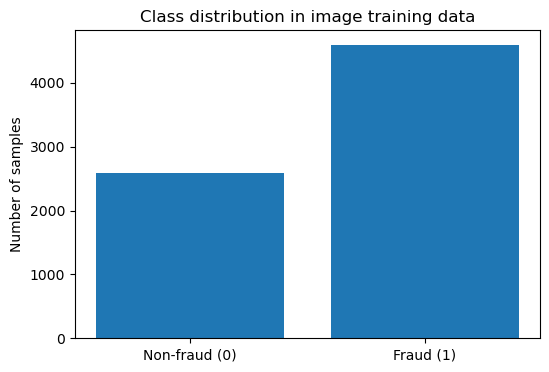

In [25]:
class_counts = train_df["final_label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["Non-fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class distribution in image training data")
plt.ylabel("Number of samples")
plt.show()


## Comparison bar chart for the 2 variants

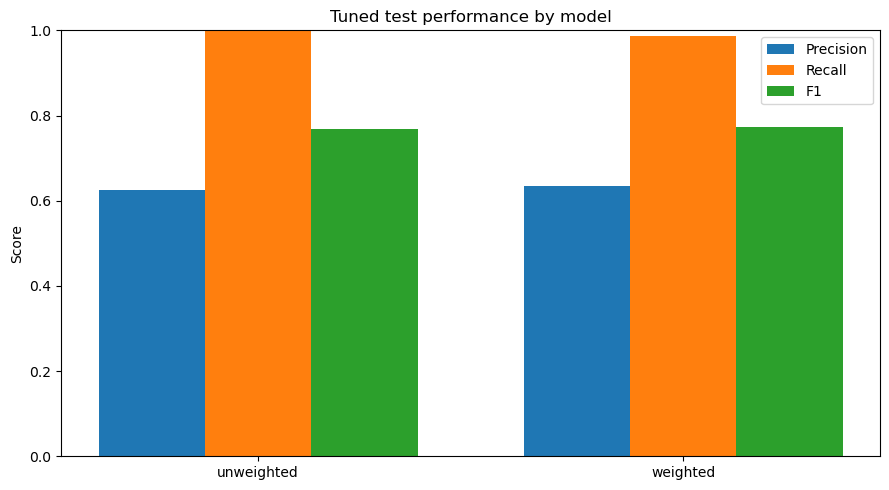

In [26]:
import numpy as np

metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]

x     = np.arange(len(comparison_df["model"]))
width = 0.25

plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_df[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_df["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Expected cost comparison

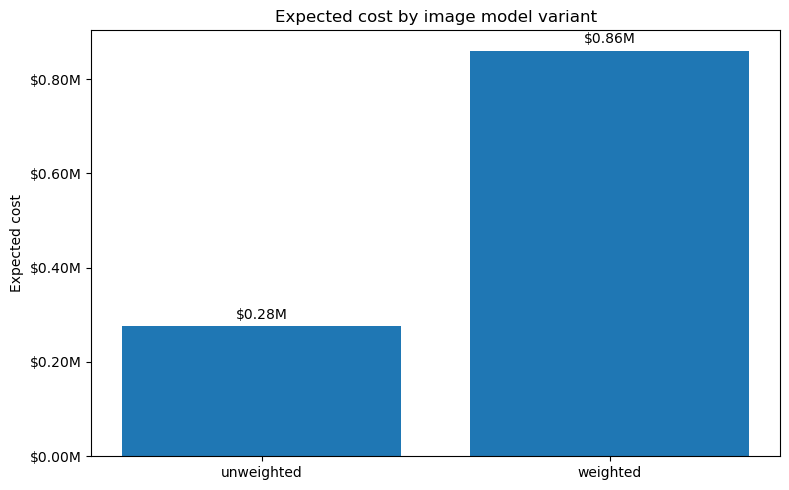

In [27]:
cost_plot_df = comparison_df.sort_values("tuned_expected_cost")

plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by image model variant")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3)
plt.tight_layout()
plt.show()


## Threshold performance plot

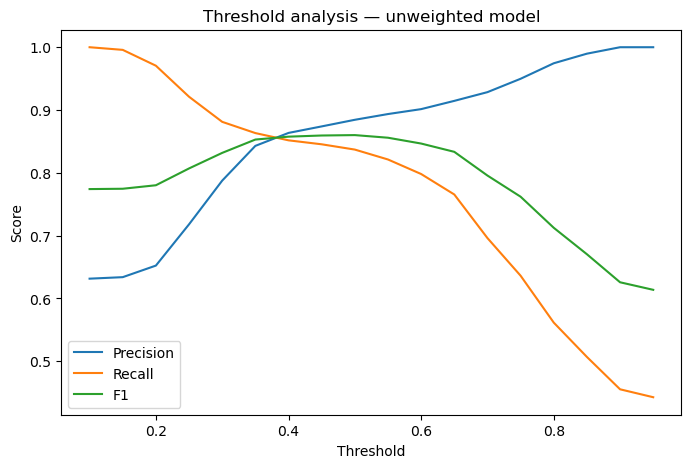

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_unweighted["threshold"],
         threshold_results_unweighted["precision"], label="Precision")
plt.plot(threshold_results_unweighted["threshold"],
         threshold_results_unweighted["recall"],    label="Recall")
plt.plot(threshold_results_unweighted["threshold"],
         threshold_results_unweighted["f1"],        label="F1")
plt.title("Threshold analysis — unweighted model")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.legend()
plt.show()


### Confusion matrices before tunning


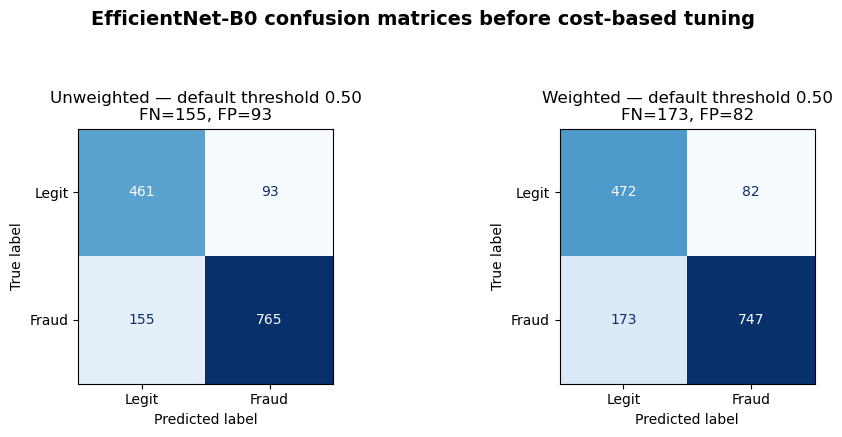

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plots = [
    (cm_default_unweighted, "Unweighted — default threshold 0.50"),
    (cm_default_weighted,   "Weighted — default threshold 0.50"),
]

for ax, (cm, title_) in zip(axes, plots):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legit", "Fraud"]
    )
    disp.plot(
        ax=ax,
        colorbar=False,
        values_format="d",
        cmap="Blues"
    )

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{title_}\nFN={fn}, FP={fp}")

plt.suptitle(
    "EfficientNet-B0 confusion matrices before cost-based tuning",
    fontsize=14,
    fontweight="bold",
    y=1.08
)

plt.tight_layout()
plt.show()

Before cost-based tuning, both EfficientNet-B0 models show balanced behavior. The unweighted model detects more fraud cases but produces slightly more false positives. The weighted model produces fewer false positives but misses more fraud cases. This shows a clear precision-recall trade-off at the default threshold.

## Tuned confusion matrices

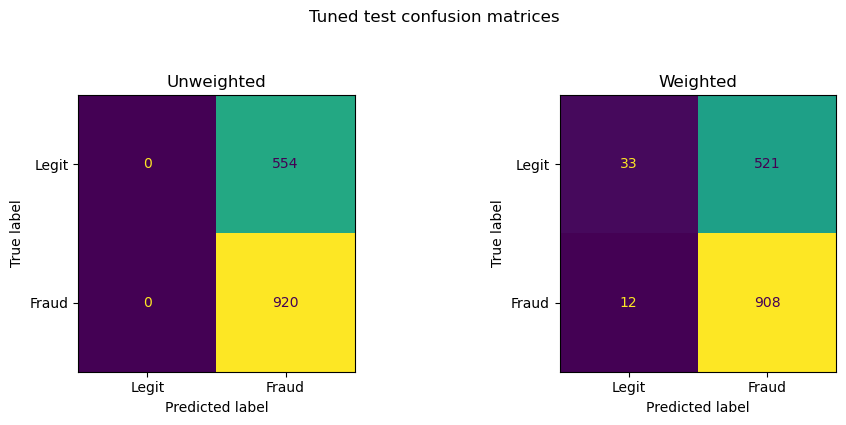

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cm, title_) in zip(axes, [
    (tuned_cm_unweighted, "Unweighted"),
    (tuned_cm_weighted,   "Weighted"),
]):
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices", y=1.05)
plt.tight_layout()
plt.show()


## Threshold analysis — precision, recall, F1

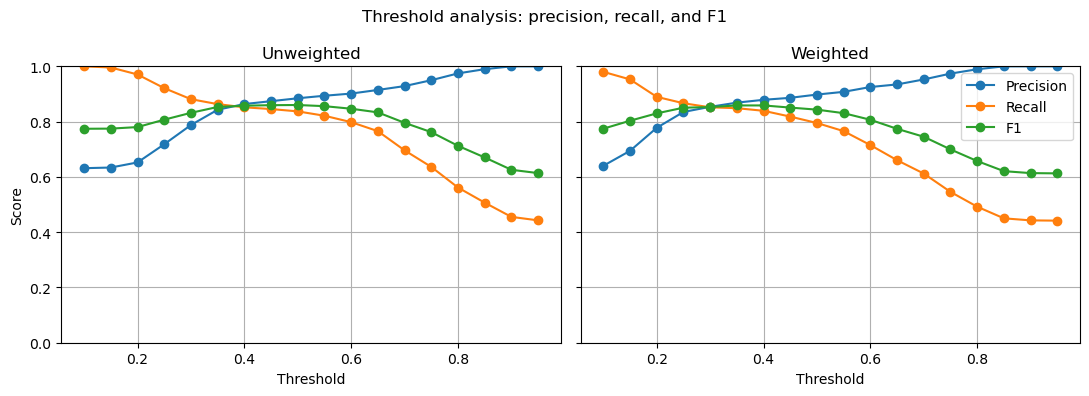

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (df, title_) in zip(axes, [
    (threshold_results_unweighted, "Unweighted"),
    (threshold_results_weighted,   "Weighted"),
]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold")
    ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score")
axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, and F1")
plt.tight_layout()
plt.show()


## Expected cost by threshold

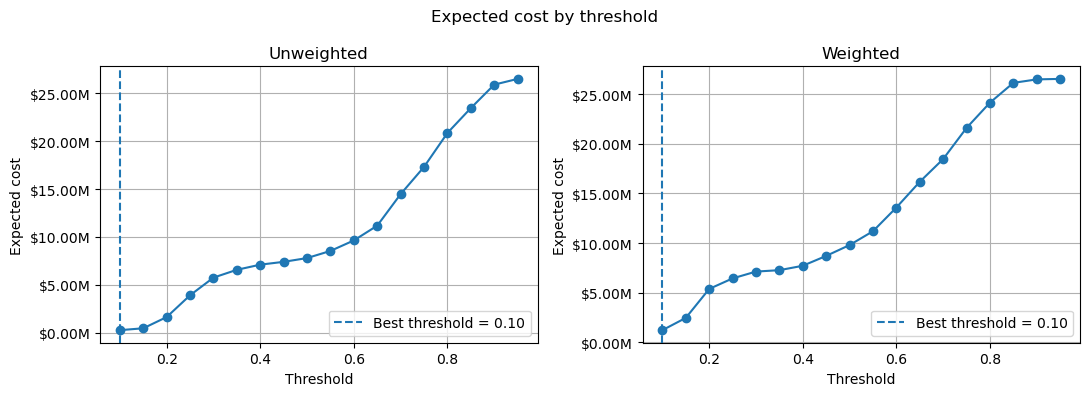

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, (df, title_) in zip(axes, [
    (cost_df_unweighted, "Unweighted"),
    (cost_df_weighted,   "Weighted"),
]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best threshold = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold")
plt.tight_layout()
plt.show()


## Precision-Recall curves

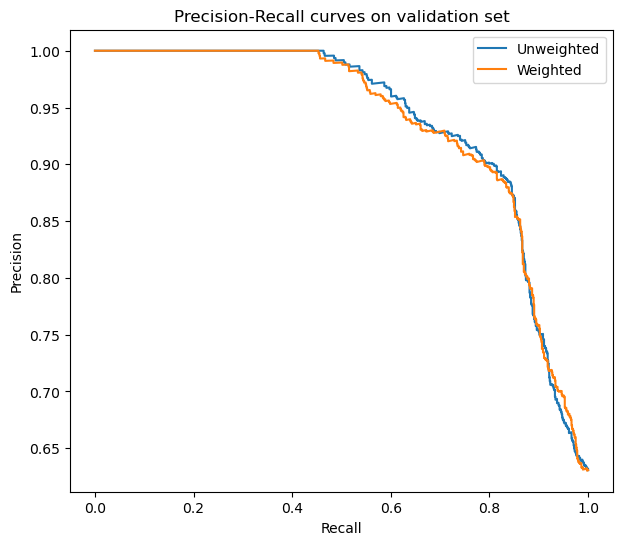

In [32]:
p_u, r_u, _ = precision_recall_curve(val_y_unweighted, val_p_unweighted)
p_w, r_w, _ = precision_recall_curve(val_y_weighted,   val_p_weighted)

plt.figure(figsize=(7, 6))
plt.plot(r_u, p_u, label="Unweighted")
plt.plot(r_w, p_w, label="Weighted")
plt.title("Precision-Recall curves on validation set")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend()
plt.show()


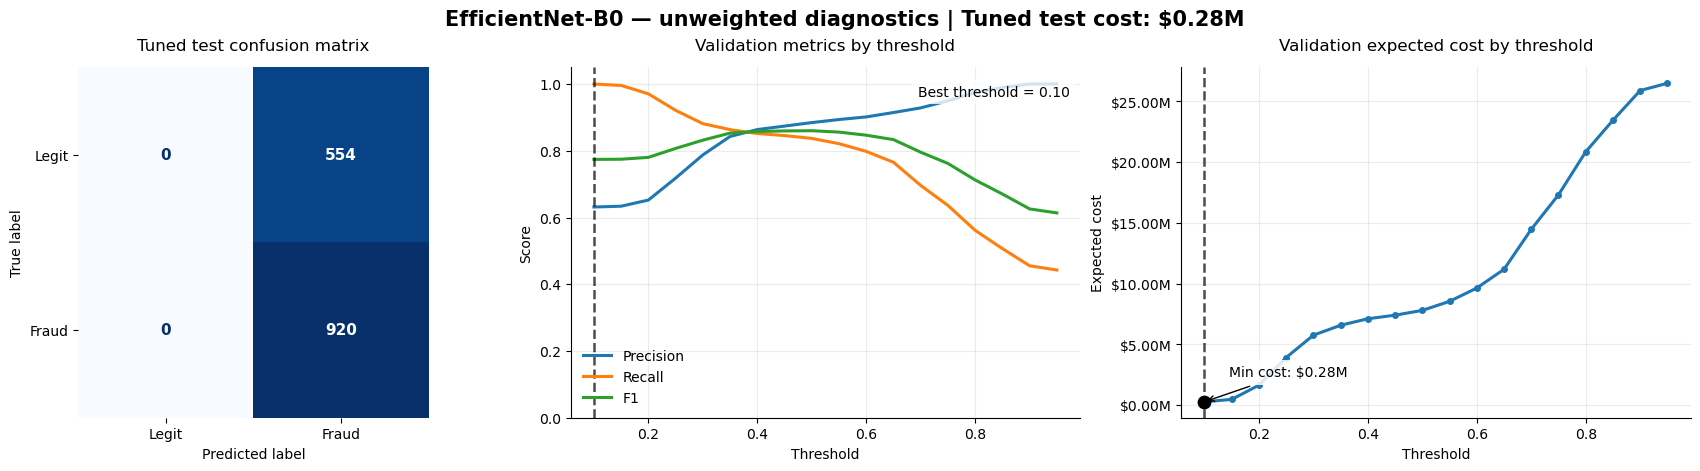

In [33]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_unweighted,
    threshold_results=threshold_results_unweighted,
    cost_df=cost_df_unweighted,
    model_name="EfficientNet-B0 — unweighted",
    save_path=RESULTS_BASE / "diagnostics_unweighted.png",
)


The unweighted EfficientNet-B0 diagnostics show the effect of cost-based threshold tuning. The selected threshold is 0.10, which gives the lowest validation expected cost.

At this threshold, the model detects all 920 fraud cases on the test set and produces no false negatives. However, it also classifies all 554 legitimate cases as fraud. This means the model achieves the lowest cost by avoiding missed fraud completely, but it loses the ability to identify legitimate cases.

The cost curve explains why this happens. Since false negatives are much more expensive than false positives, the cost function strongly prefers a very low threshold. As a result, the model becomes extremely aggressive.



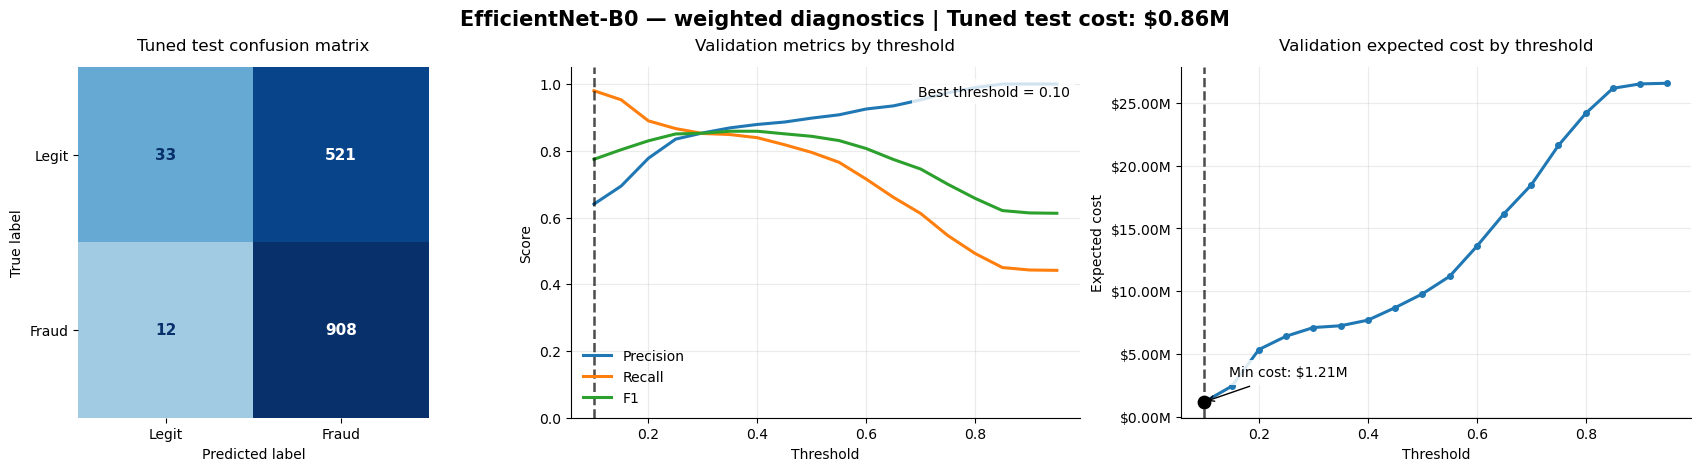

In [34]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_weighted,
    threshold_results=threshold_results_weighted,
    cost_df=cost_df_weighted,
    model_name="EfficientNet-B0 — weighted",
    save_path=RESULTS_BASE / "diagnostics_weighted.png",
)


The weighted EfficientNet-B0 diagnostics show that the selected cost-based threshold is also 0.10. At this threshold, the model detects 908 out of 920 fraud cases and misses 12. It also produces 521 false positives, while correctly identifying only 33 legitimate cases.

Compared with the unweighted EfficientNet-B0 model, the weighted model is slightly less aggressive because it keeps a small number of true negatives. However, it also misses more fraud cases. Since false negatives are much more expensive than false positives, these missed fraud cases increase the expected cost.



## Final choice

The variant with the lowest expected cost is selected as the final image-only
result, for comparison with LR, XGBoost, and the multimodal models.


In [35]:
comparison_df.to_csv(RESULTS_BASE / "comparison.csv", index=False)
print("Saved comparison to:", RESULTS_BASE / "comparison.csv")
final_choice_df = comparison_df.sort_values("tuned_expected_cost").copy()
final_choice_df


Saved comparison to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_b0\comparison.csv


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,unweighted,0.860076,0.876069,0.936963,0.860517,0.883360,0.938623,0.1,0.624152,1.000000,0.768588,277000
1,weighted,0.843279,0.875052,0.935144,0.854202,0.878216,0.936584,0.1,0.635409,0.986957,0.773095,860500
